In [1]:
import sys
sys.path.append("..")
import utils_for_cluster_first_try as utils
import utils_for_rings_and_discs as gen_and_plot_utils

import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

import importlib
importlib.reload(utils)
importlib.reload(gen_and_plot_utils)



<module 'utils_for_rings_and_discs' from 'c:\\Users\\jamac\\Desktop\\PLiCCA-code\\rings_and_discs\\utils_for_rings_and_discs.py'>

# Generate the data

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

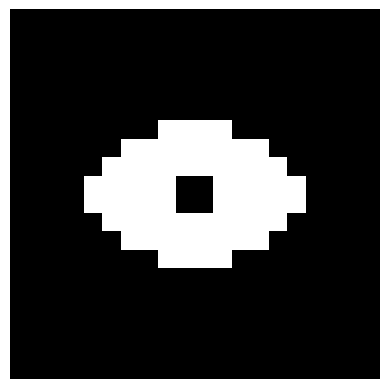

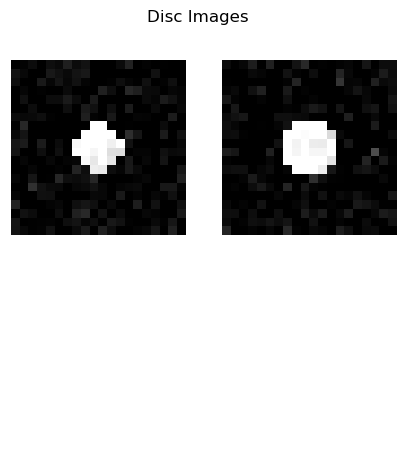

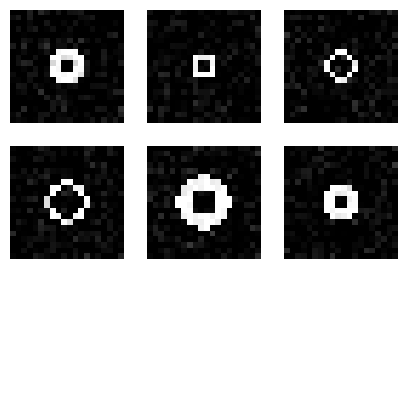

In [2]:
# Example usage to generate one ring image
r_1 = 0.1  # Radius of the hole
r_2 = 0.3  # Thickness of the ring
num_pixels = 20  # Image resolution
# Generate and display the ring image
ring_image = gen_and_plot_utils.generate_ring_image(r_1, r_2, num_pixels,aspect_ratio=1.5)
gen_and_plot_utils.display_image(ring_image)

# Example usage to generate a dataset of images
N = 10  # Total number of images
p = 10  # Length of vector X
X_decoder_var = 0.005  # Variance of Gaussian noise for X
Y_decoder_var = 0.005  # Variance of Gaussian noise for images
images, labels, X_vectors, Z_vectors, Z_original = gen_and_plot_utils.generate_image_dataset_and_X(N, p, X_decoder_var, Y_decoder_var,num_pixels=num_pixels)
gen_and_plot_utils.plot_image_dataset(images, labels)

Singular values of SigmaXY, which should be equal to lams if thetas and etas satisfy the SigmaX and SigmaY normaliziation condition:
[0.9 0.7]
[0.9, 0.7]


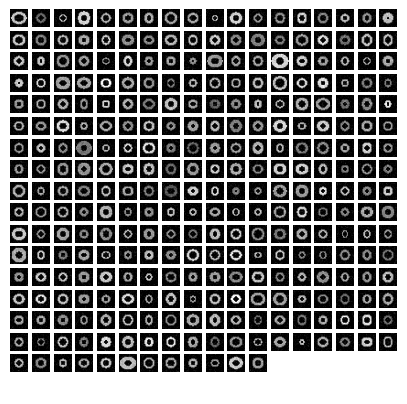

Correlation between Z[:, 2] and X[:, 2]: 0.8900
Correlation between Z[:, 3] and X[:, 3]: 0.6726
Singular values of SigmaXY, which should be equal to lams if thetas and etas satisfy the SigmaX and SigmaY normaliziation condition:
[0.9 0.7]
[0.9, 0.7]


In [4]:
N = 300  # Total number of images
q = 4  # Dimension of the latent space Z. d here is 4 because we have four parameters which determine the ring and disc images.
d = 2 # number of canonical vectors
p = 30  # Length of vector X
image_noise_var = 0.003  # Variance of Gaussian noise for images
num_pixels = 20  # Image resolution

# radius of the hole in the ring
ring_r_1_lower_bd = 0.1 # choosing 0 so we also get discs in the dataset
ring_r_1_upper_bd = 0.5

# thickness of the ring
disc_r_2_lower_bd = 0.1
disc_r_2_upper_bd = 0.5

# contrast parameter
constrast_param_lower_bd = 0.3
constrast_param_upper_bd = 1

# aspect ratio parameter
aspect_ratio_lower_bd = .7
aspect_ratio_upper_bd = 1.3
lams = [0.9, 0.7]  # Canonical correlations

# canonical vectors
thetas = np.zeros((p,d))
# thetas[0,0] = 1
#thetas[1,1] = 1
thetas[2,0] = 1
thetas[3,1] = 1

etas = np.zeros((q,d))
#etas[0,0] = 1
#etas[1,1] = 1
etas[2,0] = 1
etas[3,1] = 1


# torch.manual_seed(16)
# np.random.seed(16)

output_dict = gen_and_plot_utils.generate_images_and_X_known_cvs_dataset(N, p, q, lams, thetas, etas,num_pixels,image_noise_var,
                           ring_r_1_lower_bd, ring_r_1_upper_bd,
                           disc_r_2_lower_bd, disc_r_2_upper_bd,
                           constrast_param_lower_bd, constrast_param_upper_bd,
                           aspect_ratio_lower_bd, aspect_ratio_upper_bd)

Z = output_dict["Z"]
images = output_dict["images"]
Z_standard = output_dict["Z_standard"]
X = output_dict["X"]
Y = output_dict["Y"]
W = output_dict["W"]
gen_and_plot_utils.plot_image_dataset(images, labels = [1]*N)


# Compute correlation between Z[:, 2] and X[:, 2]
correlation_Z1_X1 = np.corrcoef(Z[:, 2], X[:, 2])[0, 1]
print(f"Correlation between Z[:, 2] and X[:, 2]: {correlation_Z1_X1:.4f}")

# Compute correlation between Z[:, 3] and X[:, 3]
correlation_Z2_X2 = np.corrcoef(Z[:, 3], X[:, 3])[0, 1]
print(f"Correlation between Z[:, 3] and X[:, 3]: {correlation_Z2_X2:.4f}")

N_val = 2500  # Total number of images in validation dataset
output_dict_val = gen_and_plot_utils.generate_images_and_X_known_cvs_dataset(N_val, p, q, lams, thetas, etas,num_pixels,image_noise_var,
                           ring_r_1_lower_bd, ring_r_1_upper_bd,
                           disc_r_2_lower_bd, disc_r_2_upper_bd,
                           constrast_param_lower_bd, constrast_param_upper_bd,
                           aspect_ratio_lower_bd, aspect_ratio_upper_bd)

Z_val = output_dict_val["Z"]
images_val = output_dict_val["images"]
Z_standard_val = output_dict_val["Z_standard"]
Y_val = output_dict_val["Y"]
X_val = output_dict_val["X"]

dataset_dict = {
    "Y": Y,
    "X": X,
    "Z": Z,
    "Z_standard": Z_standard,
    "Y_val": Y_val,
    "X_val": X_val,
    "Z_val": Z_val,
    "Z_standard_val": Z_standard_val
}

from pathlib import Path

DATASET_SAVE_PATH = Path.cwd() / "rings_and_discs_dataset.pkl"
import pickle
with open(DATASET_SAVE_PATH, "wb") as f:
    pickle.dump(dataset_dict, f)

DATASET_SAVE_PATH = Path.cwd() / "rings_and_discs_validation_dataset.pkl"
import pickle
with open(DATASET_SAVE_PATH, "wb") as f:
    pickle.dump(dataset_dict, f)